# 📊 Notebook 01 — Exploratory Data Analysis (EDA)
## Predictive Maintenance AIoT Pipeline

**Dataset :** AI4I 2020 Predictive Maintenance Dataset  
**Objectif :** Comprendre la structure des données, identifier les patterns de pannes, et préparer les insights pour le Feature Engineering.

---

## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

print("✅ Librairies importées avec succès")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")

✅ Librairies importées avec succès
   pandas     : 3.0.2
   numpy      : 2.4.4


## 2. Chargement des données

In [3]:
# Charger le dataset
df = pd.read_csv('../data/raw/ai4i2020.csv')

print(f"✅ Dataset chargé")
print(f"   Lignes    : {len(df):,}")
print(f"   Colonnes  : {len(df.columns)}")
print()
print("Aperçu des 5 premières lignes :")
df.head()

✅ Dataset chargé
   Lignes    : 10,000
   Colonnes  : 14

Aperçu des 5 premières lignes :


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Structure du dataset

In [4]:
print("=== TYPES DE DONNÉES ===")
print(df.dtypes)
print()
print("=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ Aucune valeur manquante !")
print()
print("=== STATISTIQUES DESCRIPTIVES ===")
df.describe().round(3)

=== TYPES DE DONNÉES ===
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

=== VALEURS MANQUANTES ===
✅ Aucune valeur manquante !

=== STATISTIQUES DESCRIPTIVES ===


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.005,310.006,1538.776,39.987,107.951,0.034,0.005,0.012,0.010,0.010,0.002
std,2886.896,2.000,1.484,179.284,9.969,63.654,0.181,0.068,0.107,0.097,0.099,0.044
min,1.000,295.300,305.700,1168.000,3.800,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2500.750,298.300,308.800,1423.000,33.200,53.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,5000.500,300.100,310.100,1503.000,40.100,108.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,7500.250,301.500,311.100,1612.000,46.800,162.000,0.000,0.000,0.000,0.000,0.000,0.000
max,10000.000,304.500,313.800,2886.000,76.600,253.000,1.000,1.000,1.000,1.000,1.000,1.000


## 4. Analyse de la variable cible — `Machine failure`
> C'est la colonne qu'on cherche à prédire : 0 = normal, 1 = panne

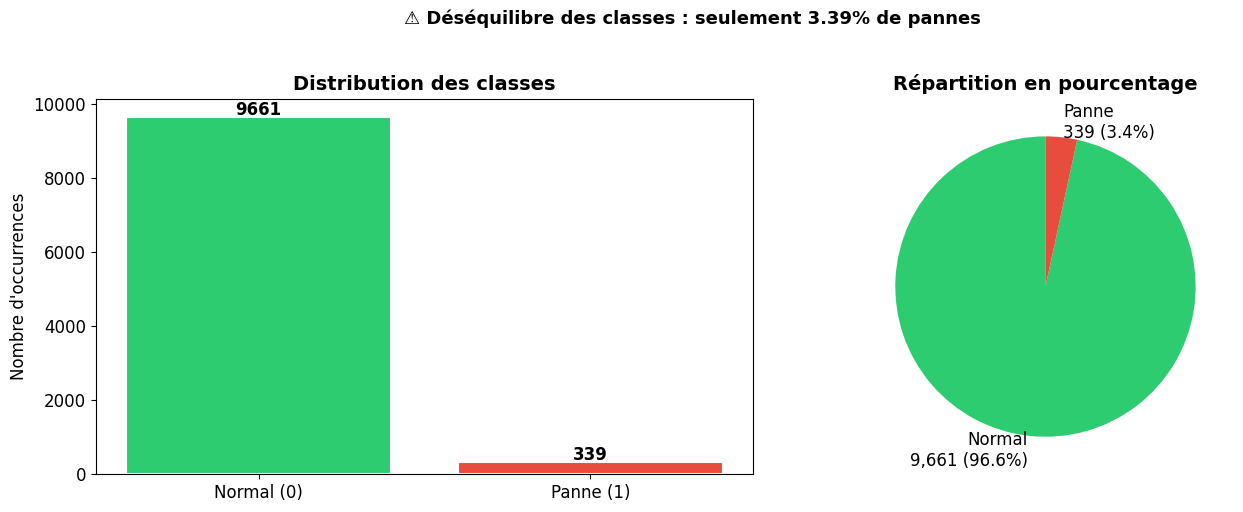

Taux de pannes : 3.39%
→ Déséquilibre important : on utilisera SMOTE lors de l'entraînement


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
counts = df['Machine failure'].value_counts()
axes[0].bar(['Normal (0)', 'Panne (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution des classes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre d\'occurrences')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pourcentages
sizes = [counts[0], counts[1]]
labels = [f'Normal\n{counts[0]:,} ({counts[0]/len(df)*100:.1f}%)',
          f'Panne\n{counts[1]:,} ({counts[1]/len(df)*100:.1f}%)']
axes[1].pie(sizes, labels=labels, colors=['#2ecc71', '#e74c3c'],
            autopct='', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Répartition en pourcentage', fontsize=14, fontweight='bold')

plt.suptitle('⚠️ Déséquilibre des classes : seulement 3.39% de pannes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Taux de pannes : {df['Machine failure'].mean()*100:.2f}%")
print("→ Déséquilibre important : on utilisera SMOTE lors de l'entraînement")

## 5. Analyse des types de pannes
> Le dataset contient 5 types de pannes : TWF, HDF, PWF, OSF, RNF

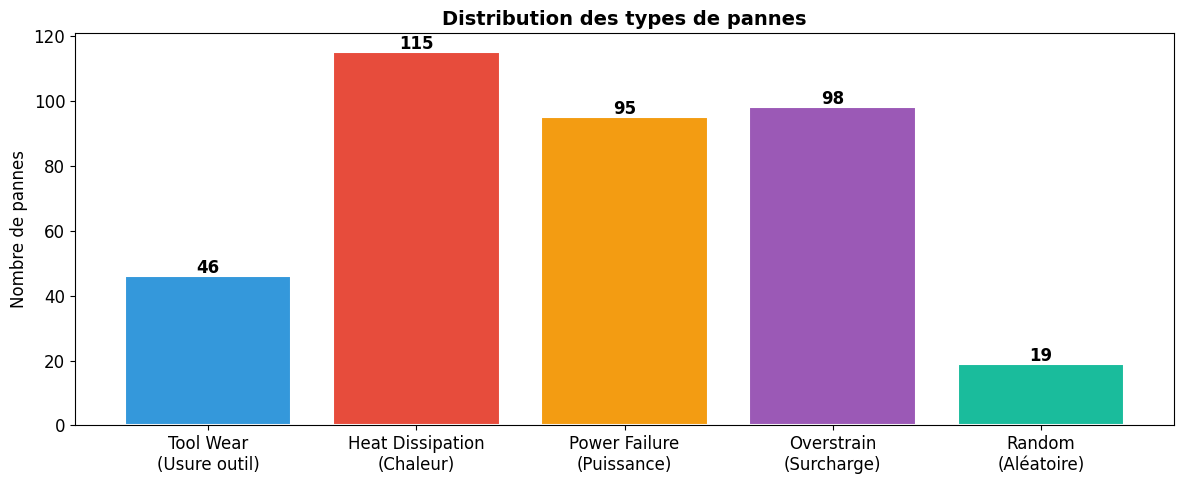

Détail des pannes par type :
  Tool Wear (Usure outil)        :  46 pannes (13.6% des pannes totales)
  Heat Dissipation (Chaleur)     : 115 pannes (33.9% des pannes totales)
  Power Failure (Puissance)      :  95 pannes (28.0% des pannes totales)
  Overstrain (Surcharge)         :  98 pannes (28.9% des pannes totales)
  Random (Aléatoire)             :  19 pannes (5.6% des pannes totales)


In [6]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_names = {
    'TWF': 'Tool Wear\n(Usure outil)',
    'HDF': 'Heat Dissipation\n(Chaleur)',
    'PWF': 'Power Failure\n(Puissance)',
    'OSF': 'Overstrain\n(Surcharge)',
    'RNF': 'Random\n(Aléatoire)'
}
counts_failures = df[failure_types].sum()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar([failure_names[f] for f in failure_types],
              counts_failures.values,
              color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c'],
              edgecolor='white', linewidth=1.5)
ax.set_title('Distribution des types de pannes', fontsize=14, fontweight='bold')
ax.set_ylabel('Nombre de pannes')
for bar, val in zip(bars, counts_failures.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/02_failure_types.png', dpi=150, bbox_inches='tight')
plt.show()

print("Détail des pannes par type :")
for f in failure_types:
    print(f"  {failure_names[f].replace(chr(10), ' '):<30} : {counts_failures[f]:>3} pannes ({counts_failures[f]/339*100:.1f}% des pannes totales)")

## 6. Distribution des features numériques

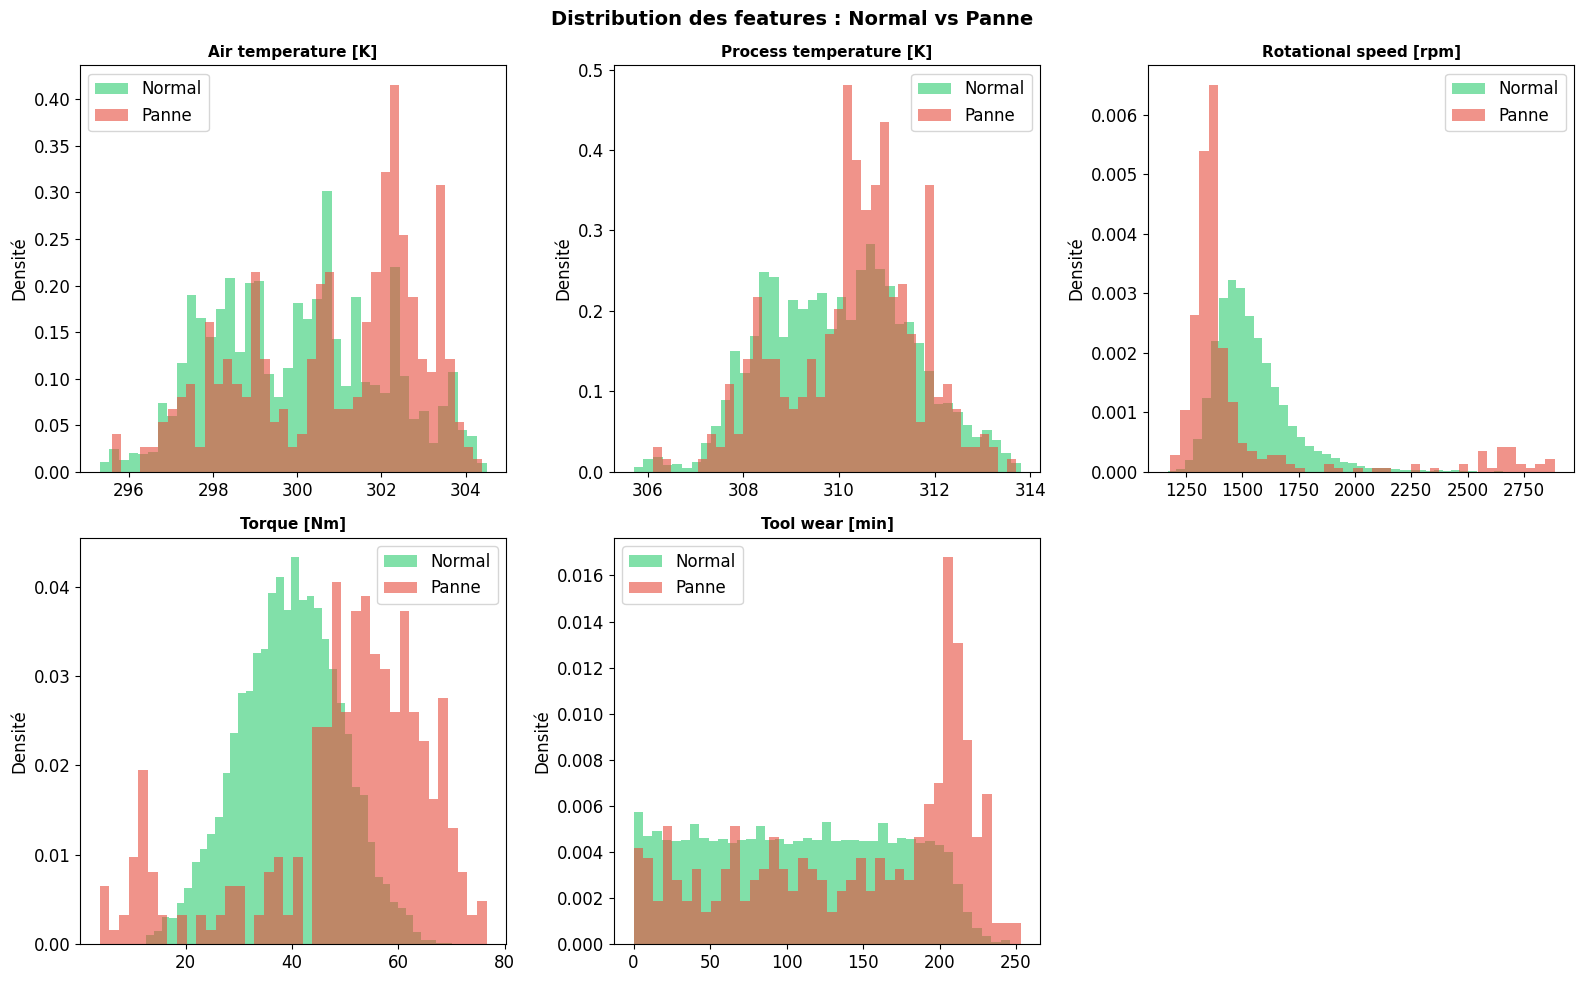

In [7]:
features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    # Normal vs Panne
    normal = df[df['Machine failure'] == 0][feat]
    panne  = df[df['Machine failure'] == 1][feat]

    axes[i].hist(normal, bins=40, alpha=0.6, color='#2ecc71', label='Normal', density=True)
    axes[i].hist(panne,  bins=40, alpha=0.6, color='#e74c3c', label='Panne',  density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Densité')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Distribution des features : Normal vs Panne', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Matrice de corrélation

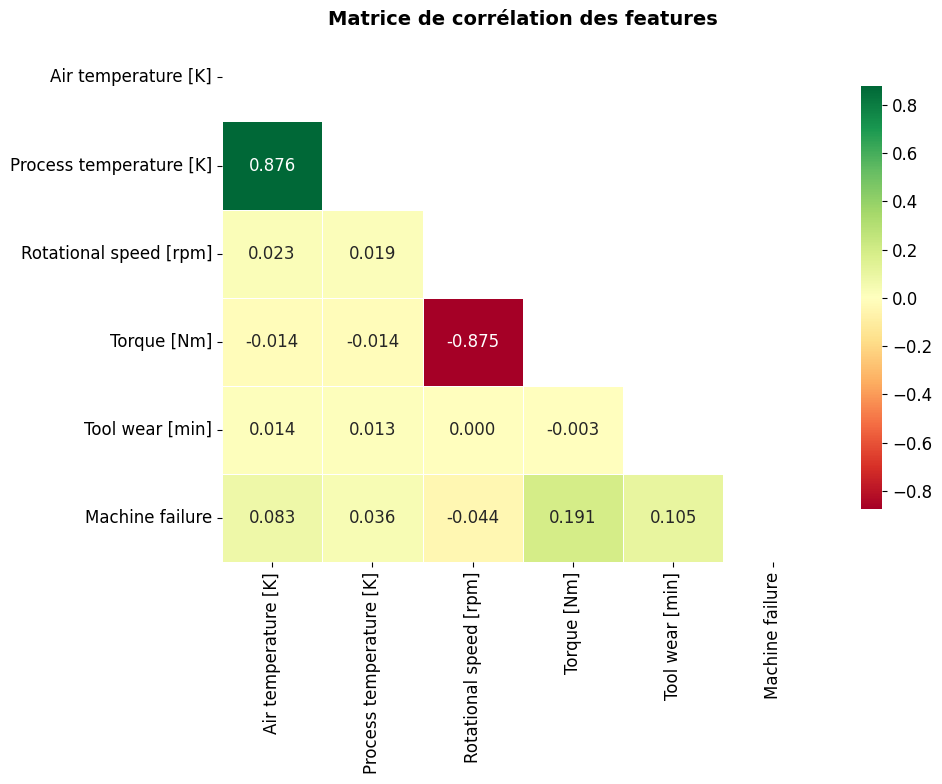

Corrélations avec Machine failure :
  Torque [Nm]                         : +0.191  █████
  Tool wear [min]                     : +0.105  ███
  Air temperature [K]                 : +0.083  ██
  Process temperature [K]             : +0.036  █
  Rotational speed [rpm]              : -0.044  █


In [8]:
numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]',
                'Tool wear [min]', 'Machine failure']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Matrice de corrélation des features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Corrélations avec Machine failure :")
corr_target = corr_matrix['Machine failure'].drop('Machine failure').sort_values(ascending=False)
for feat, val in corr_target.items():
    bar = '█' * int(abs(val) * 30)
    print(f"  {feat:<35} : {val:+.3f}  {bar}")

## 8. Boxplots — Comparaison Normal vs Panne

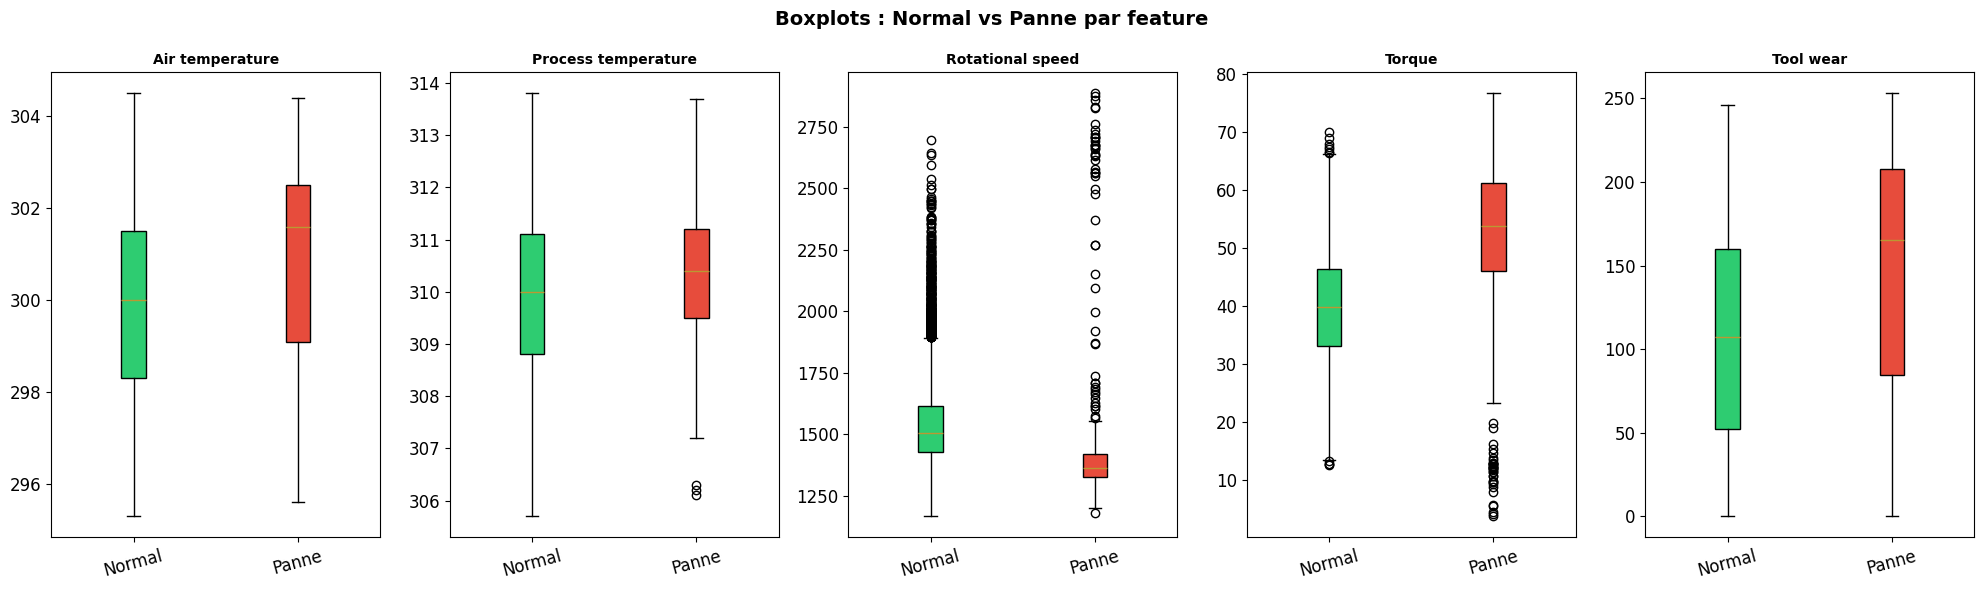

In [9]:
features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, feat in enumerate(features):
    data_plot = [df[df['Machine failure']==0][feat].values,
                 df[df['Machine failure']==1][feat].values]
    bp = axes[i].boxplot(data_plot, labels=['Normal', 'Panne'],
                         patch_artist=True, notch=False)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[i].set_title(feat.split('[')[0].strip(), fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Boxplots : Normal vs Panne par feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/05_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Analyse par type de machine (L / M / H)

Taux de panne par type de machine :
      Pannes  Total  Taux %
Type                       
H         21   1003    2.09
L        235   6000    3.92
M         83   2997    2.77


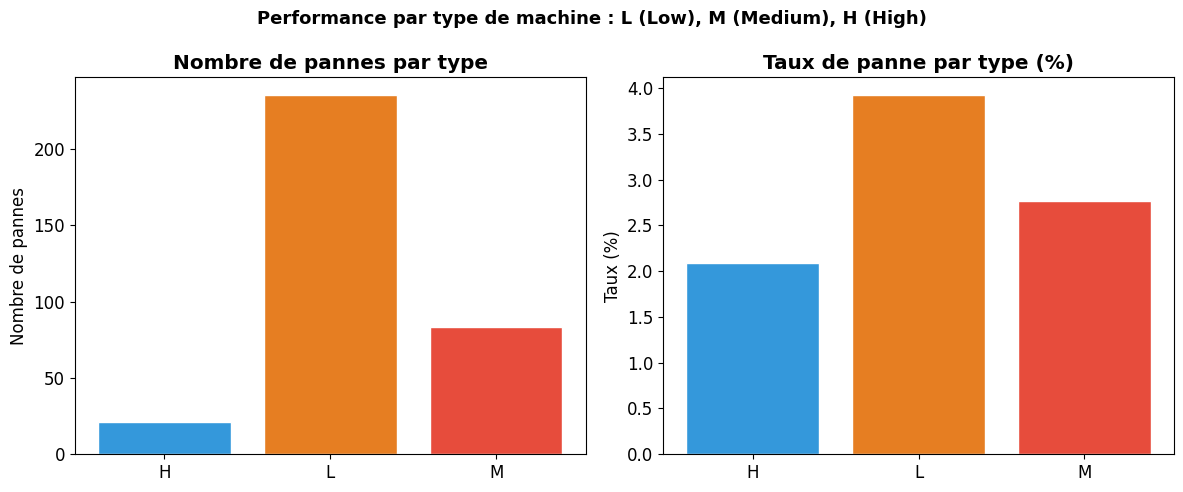

In [10]:
type_failure = df.groupby('Type')['Machine failure'].agg(['sum', 'count', 'mean'])
type_failure.columns = ['Pannes', 'Total', 'Taux']
type_failure['Taux %'] = (type_failure['Taux'] * 100).round(2)

print("Taux de panne par type de machine :")
print(type_failure[['Pannes', 'Total', 'Taux %']])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(type_failure.index, type_failure['Pannes'],
            color=['#3498db', '#e67e22', '#e74c3c'], edgecolor='white')
axes[0].set_title('Nombre de pannes par type', fontweight='bold')
axes[0].set_ylabel('Nombre de pannes')

axes[1].bar(type_failure.index, type_failure['Taux %'],
            color=['#3498db', '#e67e22', '#e74c3c'], edgecolor='white')
axes[1].set_title('Taux de panne par type (%)', fontweight='bold')
axes[1].set_ylabel('Taux (%)')

plt.suptitle('Performance par type de machine : L (Low), M (Medium), H (High)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/06_failure_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 📋 Conclusions & Insights

### Ce qu'on a découvert :

| # | Insight | Impact |
|---|---------|--------|
| 1 | **Déséquilibre sévère** : 3.39% de pannes seulement | → Utiliser SMOTE + `scale_pos_weight` dans XGBoost |
| 2 | **Tool wear** : forte corrélation avec les pannes | → Feature très importante pour le modèle |
| 3 | **Torque** : valeurs anormalement élevées lors des pannes | → Bonne feature discriminante |
| 4 | **Température** : légère élévation avant panne | → Ajouter `temp_diff` en feature engineering |
| 5 | **HDF (Heat Dissipation)** : type de panne le plus fréquent | → Surveiller la température en priorité |
| 6 | **Type H** : taux de panne plus élevé | → Encoder le type comme feature catégorielle |

### Prochaine étape :
→ **Notebook 02 : Feature Engineering** — créer de nouvelles features à partir de ces insights